In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

from paiskintonetools import setup_matplotlib  #  type:ignore
import scienceplots  # noqa

from scipy.stats import linregress

setup_matplotlib(dpi=200)

In [2]:
figure2_bicep = pd.read_csv("plotted_data/figure2_bicep.csv", index_col=0)

In [3]:
figure2_bicep.head()

,ITA,Fitzpatrick Type,mean_positive_700,mean_all_700,std_700,mean_positive_800,mean_all_800,std_800,mean_positive_1080,mean_all_1080,std_1080
0,-63.590000,6,0.003108,-0.000413,0.005522,0.002186,-0.000444,0.003872,0.000652,-0.000490,0.001021
1,-39.706667,6,0.003981,-0.000347,0.007192,0.002400,-0.000290,0.004153,0.000740,-0.000434,0.001096
2,-31.844000,5,0.003877,-0.000595,0.007283,0.002081,-0.000442,0.003619,0.000658,-0.000719,0.001117
3,-29.898000,6,0.004130,0.000440,0.008914,0.002828,0.000116,0.005445,0.001027,-0.000348,0.001374
4,-29.470000,6,0.003660,-0.000326,0.006709,0.002255,-0.000341,0.003532,0.001073,-0.000897,0.001612


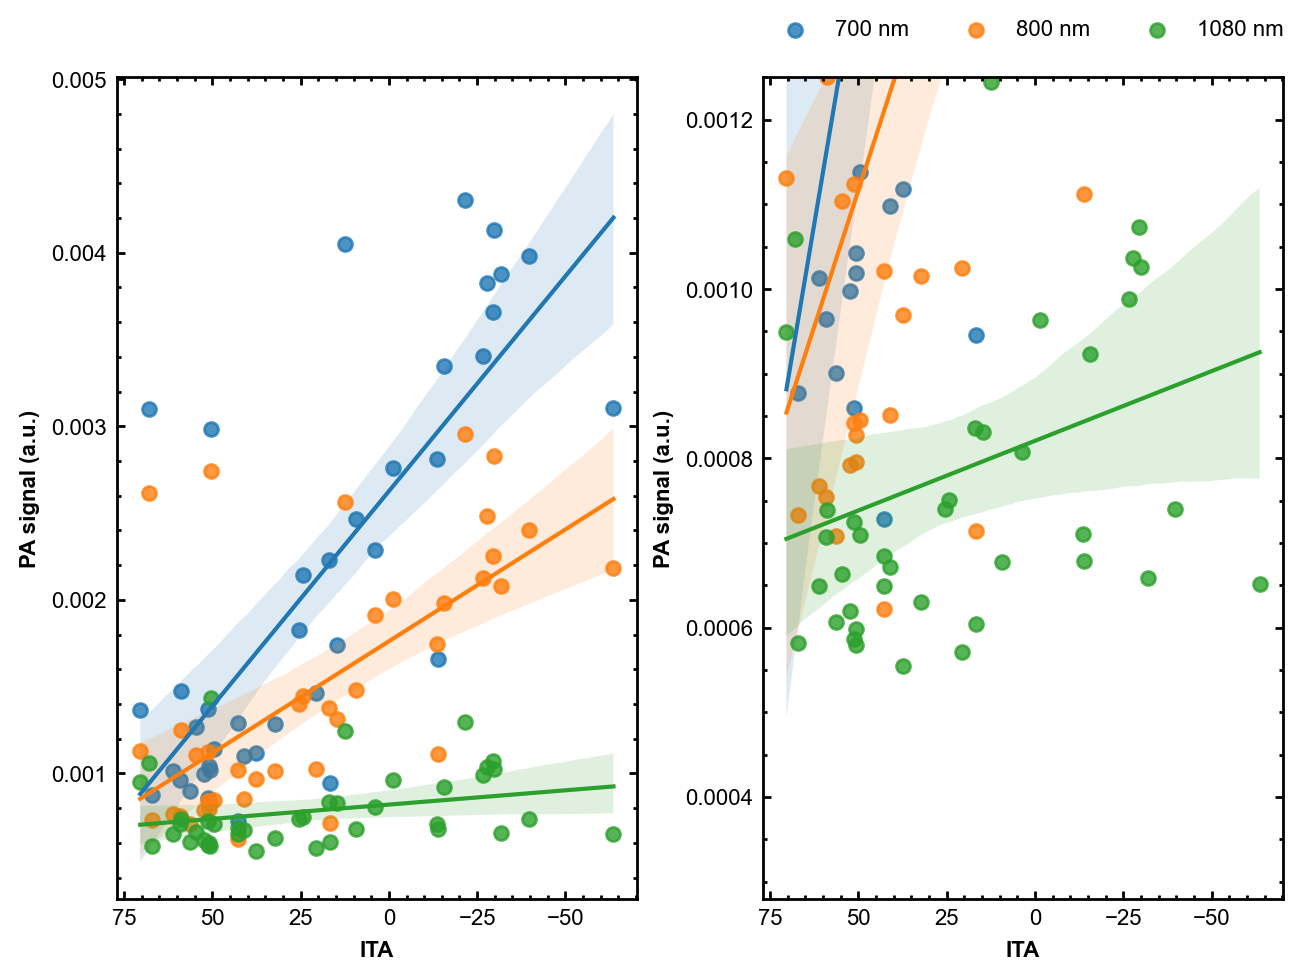

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)
sns.regplot(figure2_bicep, x="ITA", y="mean_positive_700", ax=ax1, label="700 nm")
sns.regplot(figure2_bicep, x="ITA", y="mean_positive_800", ax=ax1, label="800 nm")
sns.regplot(figure2_bicep, x="ITA", y="mean_positive_1080", ax=ax1, label="1080 nm")
ax1.invert_xaxis()
ax1.set_ylabel("PA signal (arb. units)")

sns.regplot(figure2_bicep, x="ITA", y="mean_positive_700", ax=ax2)
sns.regplot(figure2_bicep, x="ITA", y="mean_positive_800", ax=ax2)
sns.regplot(figure2_bicep, x="ITA", y="mean_positive_1080", ax=ax2)
ax2.set_ylim([None, 0.00125])
ax2.set_ylabel("PA signal (arb. units)")
fig.legend(loc="outside upper right", ncols=3)
plt.show()

In [ ]:
for y in ["mean_positive_700", "mean_positive_800", "mean_positive_1080"]:
    print(linregress(figure2_bicep["ITA"], figure2_bicep[y]).pvalue < 0.001)  # type:ignore

for y in ["mean_positive_700", "mean_positive_800", "mean_positive_1080"]:
    print(linregress(figure2_bicep["ITA"], figure2_bicep[y]).pvalue < 0.001)  # type:ignore

True
True
False
True
True
False


In [ ]:
for y in ["mean_positive_700", "mean_positive_800", "mean_positive_1080"]:
    slopes = np.zeros(10000)
    for i in range(slopes.size):
        c = np.random.choice(
            np.arange(figure2_bicep.shape[0]),
            size=(figure2_bicep.shape[0],),
            replace=True,
        )
        sample = figure2_bicep.iloc[c]
        slopes[i] = linregress(sample["ITA"], sample[y]).slope  # type:ignore
    print(1 - np.mean(slopes < 0))
    print(np.percentile(slopes, 2.5))
    print(np.percentile(slopes, 100 - 2.5))

0.0
-3.1610122181384094e-05
-1.800737580687251e-05
0.0
-1.7688898660485864e-05
-7.965515420021368e-06
0.03259999999999996
-3.705329574647157e-06
9.192534985504481e-08
